<a href="https://colab.research.google.com/github/muxicolin/SC1003-Lab-Project/blob/main/%E2%80%9CSorting_Test_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC1003 Mini Project: Team Formation Algorithm
## By Group 2
### Group Members
- TAN JUN HONG, KEAGAN (KTAN261@e.ntu.edu.sg)
- FELICIA LAI QIAN HUI (feli0065@e.ntu.edu.sg)
- LIU JIALIN (LIUJ0179@e.ntu.edu.sg)
- ZHU JIAYU (ZH0045YU@e.ntu.edu.sg)

Our algorithm groups students into balanced and diverse teams based on:
- **Tutorial group**
- **School affiliation**
- **Gender**
- **CGPA band (L / M / H)**



##Problem Decomposition
(the process of breaking a large, complex problem into smaller, independent and manageable sub-problems)


1. Data Input and Cleaning
    - Create functions to handle the reading, cleaning and standardisation of data
    - Functions used: read_csv(), normalize_gender() and normalize_school()
    - Their purpose: strips whitespace, coverts CGPA to float and normalises gender(e.g. "female", "F" -> "Female")
    - This ensures that all data is consistent and structured before any processing

2. Grouping students
    - Separate students by their tutorial
    - Function used: group_by_key()
    - Avoids mixing students from different tutorial groups when we do our groupings later

3. Data analysis of CGPA scores
    - CGPA differs across tutorials, so within each tutorial group, the students are arranged in order of their CGPA from low to high
    - Functions used: bands(), band_of_cgpa()
    - bands(values) -> finds CGPA cutoffs for L/M/H bands
    - band_of_cgpa() -> labels a CGPA as "L", "M", or "H"
    - Each group is now standardized internally, so teams would not consist predominantly of students with very high or very low CGPAs

4. "Rarity" of students
    - Counts how common each school, gender, and Band is in the tutorial
    - Function used: rarity_score_map(students)
    - Assigns each student a rarity score such that students with rare combinations (e.g. the only female student from SPMS) is assigned a higher score
    - Allows algorithm to prioritise these rare cases first, which improves fairness of group distribution later on

5. Team quality
    - How to know whether adding a student to a team improves or worsens balance?
    - Function used: team_penalty(team, candidate=None)
    - For a team, penalty would be added for:
      ~ Too many students from same school/same gender
      ~ Too many students from the same CGPA band (>=3 of L/M/H)
      ~ Missing all 3 CGPA bands
      ~ Larger team size
    - Returns a numerical penalty if any of the above criteria is met (lower value= better team)

6. Team formation (Core Algorithm)
    - Assign students in a balanced way
    - Function used: make_teams_for_one_group(students_in_group)
    - Compute bands (L/M/H labels), rarity scores, then sort students by rarity (descending), then CGPA, then ID
    - For each student (rarest first), try placing them in every non-full team
    - Team with lowest penalty is chosen
    - Uses Local Swap, where 2 members from 2 teams are picked and swapped if it lowers total penalty
    
7. Output Labelling
    - After teams are formed, the nested data structure (teams inside tutorials) must be flattened and labelled for saving
    - Function used: label_and_flatten()
    - Assigns readable team labels like "G-17-T01", "G-17-T02"
    - Converts nested list of teams into one flat list of rows
    - Adds "Team Assigned" field to each student if they have already been assigned a team

8. Evaluation
    - Verify how well the algorithm balanced diversity in terms of school, gender and CGPA
    - Function used: check_majority_ok(counts) and evaluate(all_teams)
    - Calculate the percentage of teams with no school majority, no gender majority,percentage of teams containing all 3 CGPA bands as well as average
   entropy for school and gender diversity

9. Output and Visualisation
    - The results should be interpretable and reusable
    - Functions used: write_csv(), plot_summary(), band_distribution_per_team()
    - write_csv() -> saves final team list with headers
    - plot_summary(summary) -> bar chart of diversity metrics
    - band_distribution_per_team(all_teams) -> stacked bar chart of L/M/H per team

10. Integration of all steps
    - Combine all steps in a logical workflow
    - Functions used: run(input_csv, output_csv, verbose = True)
    - Ties all above components together in sequence



#Main process
procedure FORM_TEAMS(file_path, team_size):
    READ_CSV(file_path)
    CLEAN_DATA(records)
    GROUP_BY(records, "Tutorial Group")

    set empty dictionaries #all_teams=[]

    for each tutorial, students in groups:
        assignment_1 #ASSIGN_CGPA_BANDS(students)
        assignment_2 #COMPUTE_RARITY(students)
        assignment_3 #GREEDY_ASSIGN(students, team_size)
        assignment improvement #IMPROVE_TEAMS(teams)
        all_teams=all_teams + teams

    WRITE_CSV("team_output.csv", all_teams)
    EVALUATE_TEAMS(all_teams)


#Greedy assignment(depending on RARITY)
procedure GREEDY_ASSIGN(students, team_size):
    teams=INITIALIZE_EMPTY_TEAMS(ceil(len(students) / team_size))
    sort students by RARITY descending

    for each student in students:
        best_team=null
        min_penalty=infinity

        for each team in teams:
            if TEAM_NOT_FULL(team, team_size):
                penalty_increase=PENALTY(team + student) - PENALTY(team)
                if penalty_increase < min_penalty:
                    min_penalty=penalty_increase
                    best_team=team

        ADD(student, best_team)

    return teams


#Penalty function
function PENALTY(team):
    if team empty: return 0

    gender_penalty=MAX(0, COUNT_MAJORITY(team.gender) - GENDER_LIMIT)
    school_penalty=MAX(0, COUNT_MAJORITY(team.school) - SCHOOL_LIMIT)
    cgpa_penalty=ABS(COUNT_L - COUNT_M) + ABS(COUNT_M - COUNT_H)

    return gender_penalty + school_penalty + cgpa_penalty



#Swapping
procedure IMPROVE_TEAMS(teams):
    repeat until no improvement:
        for each pair of students (A, B) from different teams:
            current_penalty=PENALTY(team(A)) + PENALTY(team(B))
            SWAP(A, B)
            new_penalty=PENALTY(team(A)) + PENALTY(team(B))
            if new_penalty >= current_penalty:
                SWAP_BACK(A, B)
    return teams


#Evaluation metrics
procedure EVALUATE_TEAMS(all_teams):
    for each team in all_teams:
        entropy_school=ENTROPY(team.school)
        entropy_gender=ENTROPY(team.gender)
        print("Team", team.id,
              "School Entropy:", entropy_school,
              "Gender Entropy:", entropy_gender)


## Step 1: Import libraries and define criteria


*   Import Python libraries

*   Set criteria for team formation to ensure diversity based on different categories.





In [ ]:
import csv
import math
import random
import statistics
from collections import Counter, defaultdict

TEAM_SIZE = 5
MAX_PER_SCHOOL = 2     # to avoid school majority
MAX_PER_GENDER = 2     # to avoid gender majority
SWAP_PASSES = 2        # number of local-fix passes (0-5 good)
MAX_SWAP_TRIES = 2000  # safety cap per pass
RANDOM_SEED = 42       # deterministic, repeatable runs

random.seed(RANDOM_SEED)

## Step 2: Data cleaning

Helper functions:
- **read_csv()**: reads the given CSV file and convert rows into dicts with types cleaned.
- **write_csv()**: outputs the final CSV file with a newly created "Team Assigned" column  
- **group_by_key()**: groups students by tutorial groups since we can only assign students from the same TG in one team
- **normalize_gender() / normalize_school()**: standardize text entries for easier analysis later

In [ ]:
# Helper functions

def read_csv(path):
    # Read records.csv and convert rows into dicts with types cleaned.
    items = []
    with open(path, newline='', encoding='utf-8') as f:
        r = csv.DictReader(f) # csv.DictReader lets me access fields by name (row["Gender"]) instead of index.
        for row in r:
            # basic normalization / cleaning
            row['Tutorial Group'] = row['Tutorial Group'].strip() # basic cleaning removing the unwanted spaces
            row['Student ID']     = row['Student ID'].strip() # basic cleaning removing the unwanted spaces
            row['Name']           = row['Name'].strip() # basic cleaning removing the unwanted spaces
            row['School']         = normalize_school(row['School']) # basic cleaning removing the unwanted spaces
            row['Gender']         = normalize_gender(row['Gender']) # basic cleaning removing the unwanted spaces
            row['CGPA']           = float(row['CGPA']) # change to float
            items.append(row)
    return items

def write_csv(path, rows):
    # Outputs the deliverable format with the required “Team Assigned” column
    # Write final CSV with Team Assigned column
    cols = ["Tutorial Group","Student ID","School","Name","Gender","CGPA","Team Assigned"]
    with open(path, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=cols)
        w.writeheader()
        for r in rows:
            w.writerow({k: r.get(k,"") for k in cols})

def group_by_key(items, key):
    # Put items into a dict keyed by 'key' value.
    # Key value is the Tutorial Group so what im doing is to group the students by tutorial.
    # This is important so that we can scope to one tutorial at a time.
    d = defaultdict(list)
    for it in items:
        d[it[key]].append(it)
    return d

def normalize_gender(g):
    # Make gender values consistent.
    # Standardizes values; avoids “Female” vs “female” vs “F” mismatches
    if not g: return "Unknown"
    x = g.strip().lower()
    if x in {"f","female","woman","girl"}: return "Female"
    if x in {"m","male","man","boy"}:      return "Male"
    return "Unknown"

def normalize_school(s):
    # Trim space and keep as-is otherwise (you can map aliases if needed).
    return s.strip()

## Step 3: Assigning CGPA bands within each tutorial

Determine **bands** (cutoff at 1/3 and 2/3) within each tutorial group  and allocate the students into 3 bands:
- **Low (L)**: CGPA ≤ q1  
- **Medium (M)**: CGPA between q1 and q2  
- **High (H)**: ≥ q2

This allows *local fairness* because most tutorial groups do not have identical CGPA distributions.

In [ ]:
def bands(values):
    # Return (q1, q2) for L/M/H bands using simple rank cut points.
    xs = sorted(values)      # step 1: sort cgpas from lowest to highest
    n = len(xs)              # count how many students
    if n == 0:               # if empty, avoid crash
        return (0.0, 0.0)
    q1_index = round((n-1)*(1/3))  # find 1/3 position
    q2_index = round((n-1)*(2/3))  # find 2/3 position
    return xs[q1_index], xs[q2_index]

def band_of_cgpa(cgpa, q1, q2):
    # Label a student's CGPA as Low/Medium/High within its tutorial group
    if cgpa <= q1: return "L"
    if cgpa >= q2: return "H"
    return "M"

# cgpa distributions vary across groups.
# if we used one global cutoff (e.g. across 6000 students), some tutorials could end up with all “L” or all “H”.
# by computing bands within each tutorial, the team formation is locally fair, every tutorial has its own balance of L/M/H students.

## Step 4: Diversity measure (by applying Entropy)

Entropy is used to quantify and measure how the diversity of the teams.  
Higher entropy value means more mixed.  
For example:
- Team 1 = {'Female':5}   **Entropy = 0**
- Team 2 = {'Male':3, 'Female':2}   **Higher entropy**

In [ ]:
def entropy(counts): # This function takes in a Counter dictionary (e.g., {'Male':3, 'Female':2}).
    # Higher means more mix. Used for evaluation charts if you want.
    total = sum(counts.values()) # Counts how many total members we’re considering — e.g., 5 students in the team.
    if total == 0: # Safety check: if somehow there are no members, just return 0 (no diversity).
        return 0.0
    ent = 0.0 # Start a running total for entropy.
    for c in counts.values(): # For each category (e.g., each school or gender):
        if c > 0:
            p = c / total # Compute its probability p = count / total
            ent -= p * math.log(p, 2) # Add its contribution -p * log₂(p) to entropy
    return ent # Returns a single float (e.g., 0.0 to ~1.5 depending on number of categories).

## Step 5: Rarity score

 When forming teams, if we start by placing the “common” profiles first (40 NBS males with similar CGPAs), the “rare” ones (the only High-CGPA CCDS student) may end up left at the end, **unable to be properly balanced into a team**.

Hence, we calculate each student's rarity score based on how uncommon their School, Gender, and CGPA Band (L/M/H) are within their tutorial group:


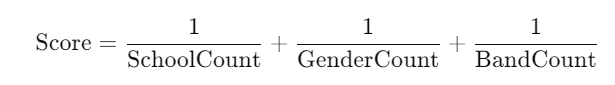

**Higher score = More rare profile**

Students with higher rarity are allocated first in the greedy algorithm.

This ensures rare profiles get considered earlier, improving diversity and fairness in later stages.

   

In [ ]:
# Scoring and placement

def rarity_score_map(students):

    # Count how common each attribute is
    school_count = Counter(s['School'] for s in students) # Uses Python’s built-in Counter to count how many times each category appears.
    gender_count = Counter(s['Gender'] for s in students) # Uses Python’s built-in Counter to count how many times each category appears.
    band_count   = Counter(s['Band']   for s in students) # Uses Python’s built-in Counter to count how many times each category appears.

    """
    Example (within one tutorial):
    school_count = {'NBS': 20, 'EEE': 15, 'SPMS': 10, 'CCDS': 5}
    gender_count = {'Male': 30, 'Female': 20}
    band_count   = {'L': 17, 'M': 16, 'H': 17}

    These counts tell us which characteristics are common and which are rare.
    Many from NBS, NBS is common (low rarity).
    Few from CCDS, CCDS is rare (high rarity).
    """

    # Creates an empty dictionary to store scores. Key = Student ID, Value = their rarity score.
    scores = {}
    for s in students:
        # Loop through all students and compute their score
        # So we know exactly how common that profile is in the tutorial.
        sc = school_count[s['School']] # sc = number of people from the same school
        gc = gender_count[s['Gender']] # gc = number of people of the same gender
        bc = band_count[s['Band']] # bc = number of people with the same band
        # safe guards
        sc = sc if sc > 0 else 1
        gc = gc if gc > 0 else 1
        bc = bc if bc > 0 else 1
        scores[s['Student ID']] = (1/sc) + (1/gc) + (1/bc)
        """
        1/sc → rarer school gives a larger number
        1/gc → rarer gender gives a larger number
        1/bc → rarer CGPA band gives a larger number
        Then all three are added up.
        """
    return scores
    # Returns a dictionary mapping each Student ID → rarity score.

## Step 6: Team penalty function

Returns a numerical value for how "risky"  a team is with respect to the pre-determined criteria.

Penalties:
- school or gender count > 2: +100
- same CGPA band ≥3 : +15
- when team has ≥3 members but has missing bands: +2 per missing L/M/H band  
- small penalty +0.5 × team size: prevents some teams to be filled too fast

**Lower penalty = Better, more diverse team.**

Students are allocated into lower penalty groups in greedy algorithm.


In [ ]:
# Returns one number that captures how “risky” a team is with respect to the rules. Lower is better.
def team_penalty(team, candidate=None):
    """
    team: the current list of members already in the team
    candidate: (optional) a student being considered for addition
    """
    members = team[:] + ([candidate] if candidate else [])
    # Creates a copy of the team (team[:]) and, if a candidate exists, adds that one student to the list. This prevents modifying the original team.
    # These three lines count how many members share each attribute.
    school_ct = Counter(m['School'] for m in members)
    gender_ct = Counter(m['Gender'] for m in members)
    band_ct   = Counter(m['Band']   for m in members)

    # Sets up a numeric variable to accumulate penalties (the higher this number becomes, the “worse” the team).
    pen = 0.0

    # Hard-ish caps to avoid majority (>2) in a 5-person team
    for c in school_ct.values():
        if c > MAX_PER_SCHOOL:
            pen += 100 + 20*(c - MAX_PER_SCHOOL)  # big penalty
    for c in gender_ct.values():
        if c > MAX_PER_GENDER:
            pen += 100 + 20*(c - MAX_PER_GENDER)  # big penalty

    # CGPA balance: avoid >=3 of the same band
    for c in band_ct.values():
        if c >= 3:
            pen += 15 * (c - 2)

    # Reward having all three bands as team gets near full
    # If the team has at least 3 members but doesn’t yet have all 3 bands (L/M/H), it adds a small penalty (2 points per missing band).
    if len(members) >= 3:
        missing_bands = 3 - len(band_ct)
        pen += 2 * missing_bands  # small cost if not all covered

    """
    Adds a small penalty based on team size (0.5 × number of members).
    So between two equally “good” teams, the algorithm prefers adding to the one that has fewer members.
    Reason: prevents one team from being filled too fast, helps balance overall team sizes during formation.
    """
    pen += 0.5 * len(members)

    # The total penalty value is returned.
    return pen


## Step 7: Building teams for one tutorial group

 Build teams of 5 for one tutorial group.
 Steps:
1. Compute CGPA bands and label each students with (L/M/H) bands using step 3 tertile function.
2. Calculate rarity scores using step 5 functions and sort them by descending order → prioritize rarer profiles.
3. Using greedy algorithmto place each student in the team that adds up to **lowest penalty**.
4. Random **local swaps** (default 2 passes) to further improve fairness by lowering the penalty score.

In [ ]:

def make_teams_for_one_group(students_in_group):

    # Count students n; compute how many teams are needed (e.g., 50/5=10); create teams as a list of empty lists.
    # Keeps team sizes consistent and prevents overflow.

    n = len(students_in_group)
    num_teams = math.ceil(n / TEAM_SIZE)
    teams = [[] for _ in range(num_teams)]

    # 1) Band each student within this tutorial
    # Build a list of CGPAs and compute bands (q1,q2).
    # Tag each student as L, M, or H relative to peers in this tutorial.
    q1, q2 = bands([s['CGPA'] for s in students_in_group])
    for s in students_in_group:
        s['Band'] = band_of_cgpa(s['CGPA'], q1, q2)
    # Balancing ability is easier with categories than raw numbers. Doing this per tutorial avoids ruining the whole thing.

    # 2) Place rare profiles first
    # Compute a rarity score per student (rarer School + Gender + Band = higher score).
    # Sort descending by rarity (minus sign), then by CGPA (to break ties), then by ID.
    rare_map = rarity_score_map(students_in_group)
    order = sorted(
        students_in_group,
        key=lambda s: (-rare_map[s['Student ID']], s['CGPA'], s['Student ID'])
    )
    # If you place common profiles first, rare ones get “trapped” and can’t be spread fairly.
    # Rarity-first gives scarce combinations priority to improve diversity across teams.

    # 3) Greedy placement: put each student into the team that adds the least penalty
    # For each student in the rare-first order, try placing them into every non-full team.
    # Compute team_penalty(current_team, candidate).
    # Pick the team with the lowest penalty; if nearly equal, prefer the smaller team.
    # Append the student to the chosen team.
    for s in order:
        best_team_index = None
        best_pen = float('inf')
        for i, t in enumerate(teams):
            if len(t) >= TEAM_SIZE:
                continue
            p = team_penalty(t, s)
            if p < best_pen - 1e-9:
                best_pen = p
                best_team_index = i
            elif abs(p - best_pen) < 1e-9:
                # tie: prefer the team with fewer members
                if len(t) < len(teams[best_team_index]):
                    best_team_index = i
        teams[best_team_index].append(s)
    # team_penalty encodes all fairness rules into one number (no school/gender majority; avoid 3+ same band to encourage L/M/H coverage.
    # Note on 1e-9: Tiny epsilon prevents floating-point equality issues and gives a deterministic tie behaviour.

    # 4) Local swaps to reduce penalties (optional, bounded)
    # Define a helper to measure the two-team penalty sum.
    # For a few passes (e.g., 2), attempt random pairwise swaps across teams:
    # 1. pick two teams at random,
    # 2. pick one student from each at random,
    # 3. simulate swapping them,
    # 4. keep the swap only if it reduces the total penalty; else revert.
    # Exit early if a pass found no improvements; hard stop via MAX_SWAP_TRIES for safety.
    def team_sum_penalty(tA, tB):
        return team_penalty(tA) + team_penalty(tB)

    for _ in range(SWAP_PASSES):
        improved = False
        tries = 0
        while tries < MAX_SWAP_TRIES:
            tries += 1
            a, b = random.sample(range(num_teams), 2)
            if not teams[a] or not teams[b]:
                continue
            ia = random.randrange(len(teams[a]))
            ib = random.randrange(len(teams[b]))
            sa, sb = teams[a][ia], teams[b][ib]

            before = team_sum_penalty(teams[a], teams[b])

            # try swap
            teams[a][ia], teams[b][ib] = sb, sa
            after = team_sum_penalty(teams[a], teams[b])

            if after + 1e-9 < before:
                improved = True
                # keep swap
            else:
                # revert if not helpful
                teams[a][ia], teams[b][ib] = sa, sb

        if not improved:
            break
    # Greedy placement is good but not perfect. This quick, bounded local search removes obvious “bad edges” without heavy compute or complex solvers.
    return teams
    # Hands back a list of lists (teams) for this tutorial.

## Step 8: Label each team and flatten for output

When teams are formed, add a `"Team Assigned"` label like:
`G-17-T01`, `G-17-T02` to each team.

*   Take tutorial group name (e.g., "G-17") and teams index to form team labels.
*   Add 'Team Assigned' labels and flatten back into one list of rows.

This ensures output CSV file easy to read, each student's assigned group is clearly recorded.

In [ ]:

def label_and_flatten(tut_name, teams):
    out = []
    for i, team in enumerate(teams, start=1): # Loops through each team; i is the 1-based team index (1, 2, 3, …), start at 1 so no team 0.
        label = f"{tut_name}-T{i:02d}" # Formats the label as "G-17-T01", "G-17-T02", … (2-digit zero-padded).
        for s in team:
            row = dict(s)  # copy
            row["Team Assigned"] = label # Adds the required output field "Team Assigned" to this student’s row.
            out.append(row)
    return out # returns a flat list of labeled student rows for this tutorial.

## Step 9: Evaluate diversity of the resulting teams

- Percentage of teams **with no school majority**
- Percentage of teams **with no gender majority**
- Percentage of teams **with all three CGPA bands (L/M/H)**
- Average **entropy** value for school and gender distribution: show the mix

In [ ]:

# Evaluation functions

def check_majority_ok(counts):
    # No value should be >=3 in a 5-person team.
    return max(counts.values()) <= 2 # returns: True if no category reaches 3 (i.e., no majority in a 5-person team), else False.

def evaluate(all_teams): # all_teams: a list of teams; each team is a list of student dicts.
    # Return key diversity stats.
    total = len(all_teams) # total: how many teams formed.
    school_ok = 0 # count of teams without a school majority.
    gender_ok = 0 # count of teams without a gender majority.
    bands_all_three = 0 # count of teams that include L, M, and H at least once.
    ent_school_list = [] # stores per-team entropy values for School and Gender.
    ent_gender_list = []

    for T in all_teams:
        # build three distributions: sc (school counts), gc (gender counts), bc (band counts).
        sc = Counter(m['School'] for m in T)
        gc = Counter(m['Gender'] for m in T)
        bc = Counter(m['Band']   for m in T)
        # check
        if check_majority_ok(sc): school_ok += 1
        if check_majority_ok(gc): gender_ok += 1
        if len(bc) == 3:          bands_all_three += 1

        ent_school_list.append(entropy(sc))
        ent_gender_list.append(entropy(gc))

    return {
        "Total Teams": total,
        "No School Majority (%)": round(100*school_ok/total, 2) if total else 0.0,
        "No Gender Majority (%)": round(100*gender_ok/total, 2) if total else 0.0,
        "Teams w/ L,M,H Bands (%)": round(100*bands_all_three/total, 2) if total else 0.0,
        "Avg School Entropy": round(statistics.mean(ent_school_list), 3) if ent_school_list else 0.0,
        "Avg Gender Entropy": round(statistics.mean(ent_gender_list), 3) if ent_gender_list else 0.0,
    }


## Step 10: Run the full algorithm

String together all pre-defined functions logically:
1. Read and clean data  
2. Form teams by tutorial groups
3. Evaluate team results  
4. Output final CSV file

In [ ]:
# Main run

def run(input_csv="records.csv", output_csv="teams_output.csv", verbose=True):
    data = read_csv(input_csv) # Loads and cleans all rows from the CSV into a list of dictionaries (uniform schema, CGPA as float, normalized fields).
    by_group = group_by_key(data, "Tutorial Group") # Buckets students into a dict like {'G-1':[...50...], 'G-2':[...50...], ...}.

    final_rows = [] # flat list of rows (student dicts) that will be written to the output CSV (with "Team Assigned").
    all_teams = [] # list of team lists across all tutorials (for evaluation and plotting).

    for tut_name, students in sorted(by_group.items()): # loop through the tutorials
        teams = make_teams_for_one_group(students) # Build teams for this tutorial.
        all_teams.extend(teams) # Add this tutorial’s teams to the whole list.
        final_rows.extend(label_and_flatten(tut_name, teams)) # Convert nested team lists into a flat list of student rows and attach "Team Assigned" labels like "G-12-T03".

    write_csv(output_csv, final_rows) # Tutorial Group, Student ID, School, Name, Gender, CGPA, Team Assigned
    summary = evaluate(all_teams) # Compute scorecard

    if verbose:
        print("=== Team Formation Summary ===")
        for k, v in summary.items():
            print(f"{k}: {v}")
        print(f"\nWrote: {output_csv}")

    return summary, all_teams, final_rows

# Run if you want immediate output:
summary, all_teams, final_rows = run("records.csv", "teams_output.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'records.csv'

## Step 11: Visualization of Diversity Outcomes

Demonstrate the **effectiveness of our program** by visualizing the results.

1. **Bar Chart for three main metrics** based on outputs from step 9 functions
   - Displays the percentage of teams with:
     - No **School Majority**
     - No **Gender Majority**
     - Contain all **L/M/H CGPA Bands**

2. **Stacked Bar Chart** to show CGPA combination in each team
   - Shows count of students with **Low (L)**, **Medium (M)**, and **High (H)** CGPA in each team
   - A balanced mix of L/M/H within each team indicates academic diversity



In [ ]:
# --- Optional plots (matplotlib only) ---
import matplotlib.pyplot as plt
from collections import Counter

def plot_summary(summary): # makes the bar chart for your three main metrics (the ones returned from evaluate()).
    labels = [
        "No School Majority (%)",
        "No Gender Majority (%)",
        "Teams with L/M/H (%)"
    ]
    values = [
        summary["No School Majority (%)"],
        summary["No Gender Majority (%)"],
        summary["Teams w/ L,M,H Bands (%)"]
    ]
    plt.figure() # starts a new plot.
    plt.bar(labels, values) # draws the 3 bars.
    plt.ylim(0, 100) # fixes Y-axis range so you can visually compare percentages across runs.
    plt.title("Diversity Outcomes") # improves readability and aesthetics.
    plt.ylabel("Percent") # improves readability and aesthetics.
    plt.xticks(rotation=10) # improves readability and aesthetics.
    plt.show() # renders the plot.

def band_distribution_per_team(all_teams): # showing how each team’s CGPA bands (L/M/H) are distributed.
    Ls, Ms, Hs = [], [], [] # Create empty lists for L, M, H counts and team IDs.
    ids = [] # Empty list for team number
    for i, T in enumerate(all_teams, start=1): # loops through every team and gives each a sequential ID (1, 2, 3…).
        bc = Counter(m['Band'] for m in T) # counts how many times each 'Band' occurs in each team. Example: {'L': 2, 'M': 2, 'H': 1}
        ids.append(i)
        Ls.append(bc.get("L", 0)) # safely retrieves counts, defaults to 0 if missing.
        Ms.append(bc.get("M", 0)) # safely retrieves counts, defaults to 0 if missing.
        Hs.append(bc.get("H", 0)) # safely retrieves counts, defaults to 0 if missing.
    plt.figure()
    plt.bar(ids, Ls, label="L") # base layer for L students.
    plt.bar(ids, Ms, bottom=Ls, label="M") # stacks M on top of L.
    plt.bar(ids, Hs, bottom=[l+m for l,m in zip(Ls,Ms)], label="H") # stacks H on top of L+M.
    # Each bar (one per team) now shows counts of L/M/H stacked together.
    plt.title("CGPA Band Composition per Team")
    plt.xlabel("Team #")
    plt.ylabel("Count")
    plt.legend() # adds a key explaining colors.
    plt.show()

# Example:
summary, all_teams, final_rows = run("records.csv", "teams_output.csv")
plot_summary(summary)
band_distribution_per_team(all_teams)

##1. Evaluation
The program effectively achieves the goal of forming well-mixed student teams in each tutorial group.


*   100% of the teams avoids school majority
*   99.5% of the teams include all three CGPA bands



*   Rarity-based sorting is used to ensure greater fairness
*   Greedy and local swap approach ensures greater efficiency

##2. Challenges
###A. Gender Imbalance

*   Our pre-determined constraint `MAX_PER_GENDER` is to ensure each group is filled with two males and females first
*   However, since there are only two genders, one gender will definitely exceed 2 in a five man team


*   Hence our evaluation on gender appears that 0 teams avoids gender diversity
*   This is a structural limitation, not a algorithm fault


*   Improvement: relax the rule to `MAX_PER_GENDER=3`


###B. Trade-Off Between Fairness Rules


*   The program is designed to consider multiple criteria simultaneously for generating the optimal results
*   Conflicts may occur when improving one metric (e.g School balance) reduces the other (e.g CGPA mix)


*   Penalty system, greedy program and local swaps help to reduce conflicts, yet never perfect.

###C. Local Optimization


*   Local swaps improves penalty scores of teams by performing random swaps between two random teams
*   However, this approach does not ensure the optimal global arrangement across all teams


*   Despite this limitation, our results show close to 100% success in diversity


*   We conclude greedy and local swap approach is very efficient and effective when dealing with large data sets (e.g 1200+ teams, 6000 students)
















###Declaration Form
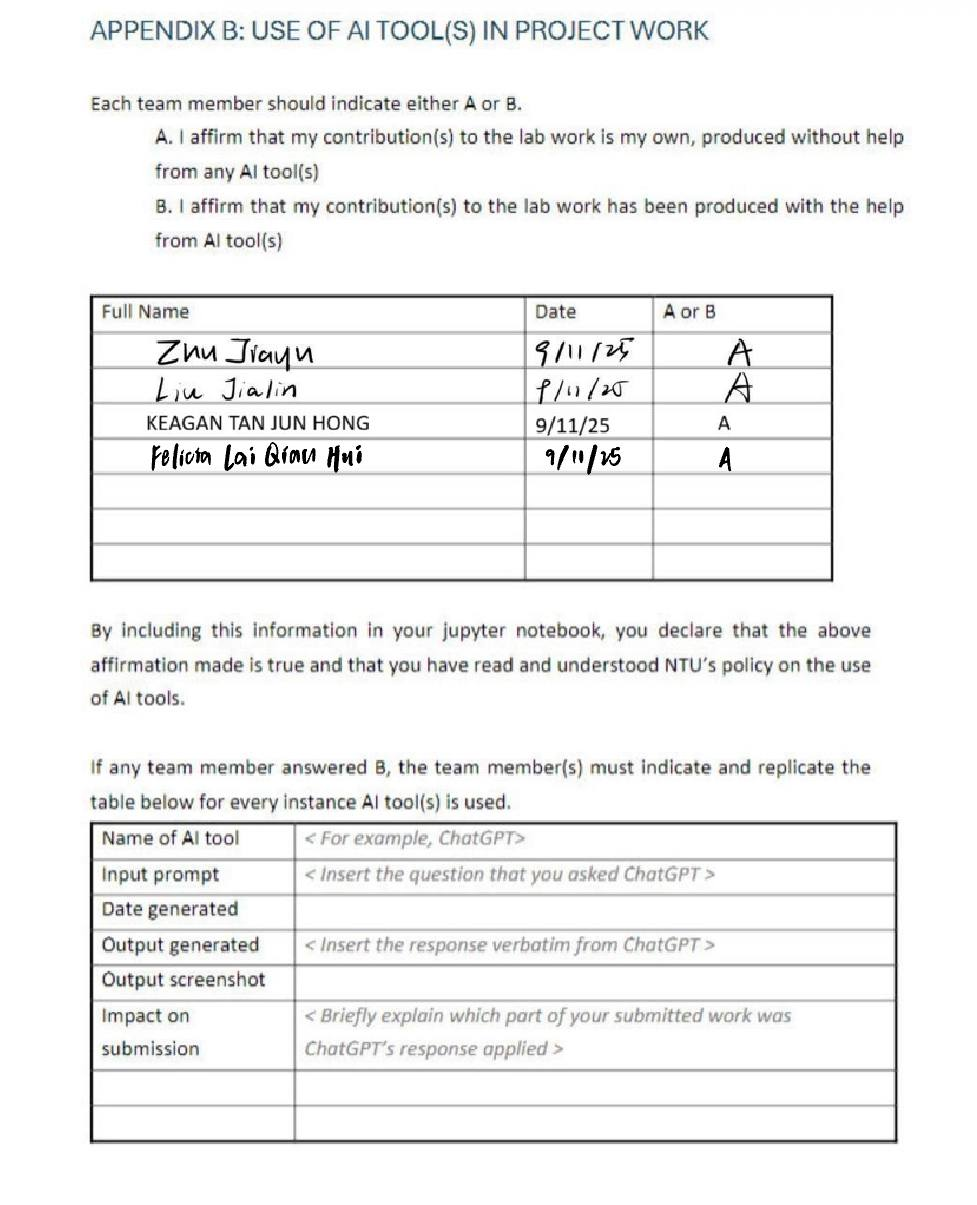

Appendix: original code

In [ ]:
import csv
from collections import defaultdict, Counter
import math, random, statistics

random.seed(42)  # repeatable results

def normalize_gender(g):
    if not g: return "Unknown"
    x = g.strip().lower()
    if x in {"f","female","woman","girl"}: return "Female"
    if x in {"m","male","man","boy"}:      return "Male"
    return "Unknown"

def normalize_school(s):
    return (s or "").strip()

def read_csv(path):
    data = []
    with open(path, newline='', encoding='utf-8') as f:
        r = csv.DictReader(f)
        for row in r:
            row["Tutorial Group"] = row["Tutorial Group"].strip()
            row["Student ID"]     = row["Student ID"].strip()
            row["Name"]           = row["Name"].strip()
            row["School"]         = normalize_school(row["School"])
            row["Gender"]         = normalize_gender(row["Gender"])
            row["CGPA"]           = float(row["CGPA"])
            data.append(row)
    return data


In [ ]:
rows = read_csv("records.csv")
print("rows:", len(rows))
print("tutorial groups (sample):", sorted({r["Tutorial Group"] for r in rows})[:10])
print("gender counts:", Counter(r["Gender"] for r in rows))
print("school count (unique):", len({r["School"] for r in rows}))


In [ ]:
def dataset_summary(rows):
    tuts = sorted({r["Tutorial Group"] for r in rows})
    cgpas = [r["CGPA"] for r in rows]
    gender_ct = Counter(r["Gender"] for r in rows)
    school_ct = Counter(r["School"] for r in rows)
    print(f"students={len(rows)}  tutorials={len(tuts)}")
    print(f"CGPA: min={min(cgpas):.2f}  max={max(cgpas):.2f}  mean={statistics.mean(cgpas):.2f}  median={statistics.median(cgpas):.2f}")
    print("gender counts:", gender_ct)
    print("top 10 schools:", school_ct.most_common(10))
    # sample 5 tutorials for a glance
    for t in tuts[:5]:
        sub = [r for r in rows if r["Tutorial Group"] == t]
        g = Counter(r["Gender"] for r in sub)
        s = Counter(r["School"] for r in sub)
        print(t, "| n=", len(sub), "| #schools=", len(s), "| top_school_share=", max(s.values())/len(sub))


In [ ]:
dataset_summary(rows)

In [ ]:
def group_by(rows, key):
    d = defaultdict(list)
    for r in rows:
        d[r[key]].append(r)
    return d

by_tut = group_by(rows, "Tutorial Group")
print("tutorials:", len(by_tut))
print("first tutorial size:", len(by_tut[sorted(by_tut)[0]]))


In [ ]:
def bands(values):
    xs = sorted(values)
    n = len(xs)
    if n == 0: return (0.0, 0.0)
    q1 = xs[round((n-1)*(1/3))]
    q2 = xs[round((n-1)*(2/3))]
    return q1, q2


In [ ]:
sample_tut = sorted(by_tut)[0]
cg = [r["CGPA"] for r in by_tut[sample_tut]]
print(sample_tut, "bands:", bands(cg))


In [ ]:
def cgpa_band(cgpa, q1, q2):
    if cgpa <= q1: return "L"
    if cgpa >= q2: return "H"
    return "M"

def add_bands_in_tutorial(students):
    q1, q2 = bands([s["CGPA"] for s in students])
    for s in students:
        s["Band"] = cgpa_band(s["CGPA"], q1, q2)

# apply to all tutorials
for t in by_tut:
    add_bands_in_tutorial(by_tut[t])

# quick check
t0 = sorted(by_tut)[0]
print("band counts in", t0, ":", Counter(s["Band"] for s in by_tut[t0]))


In [ ]:
def rarity_scores(students):
    sc = Counter(s["School"] for s in students)
    gc = Counter(s["Gender"] for s in students)
    bc = Counter(s["Band"]   for s in students)
    scores = {}
    for s in students:
        scores[s["Student ID"]] = (1/max(sc[s["School"]],1)) + (1/max(gc[s["Gender"]],1)) + (1/max(bc[s["Band"]],1))
    return scores


In [ ]:
t0 = sorted(by_tut)[0]
scores = rarity_scores(by_tut[t0])
# show first 5 highest rarity
top5 = sorted(by_tut[t0], key=lambda x: -scores[x["Student ID"]])[:5]
[(x["Student ID"], x["School"], x["Gender"], x["Band"], round(scores[x["Student ID"]],3)) for x in top5]


In [ ]:
TEAM_SIZE = 5
MAX_PER_SCHOOL = 2
MAX_PER_GENDER = 2

def team_penalty(team, candidate=None):
    members = team[:] + ([candidate] if candidate else [])
    sc = Counter(m["School"] for m in members)
    gc = Counter(m["Gender"] for m in members)
    bc = Counter(m["Band"]   for m in members)
    pen = 0.0
    # avoid school/gender majority (>2 in size-5)
    for c in sc.values():
        if c > MAX_PER_SCHOOL: pen += 100 + 20*(c-MAX_PER_SCHOOL)
    for c in gc.values():
        if c > MAX_PER_GENDER: pen += 100 + 20*(c-MAX_PER_GENDER)
    # avoid >=3 of same band
    for c in bc.values():
        if c >= 3: pen += 15*(c-2)
    # reward having all bands as team fills
    if len(members) >= 3:
        pen += 2 * (3 - len(bc))
    # mild nudge: smaller teams first
    pen += 0.5 * len(members)
    return pen


In [ ]:
def make_teams_for_tutorial(students):
    # ensure bands are present
    add_bands_in_tutorial(students)
    # rarity order
    scores = rarity_scores(students)
    order = sorted(students, key=lambda s: (-scores[s["Student ID"]], s["CGPA"], s["Student ID"]))
    num_teams = math.ceil(len(students)/TEAM_SIZE)
    teams = [[] for _ in range(num_teams)]
    # place one by one
    for s in order:
        best_i, best_pen = None, float("inf")
        for i, team in enumerate(teams):
            if len(team) >= TEAM_SIZE:
                continue
            p = team_penalty(team, s)
            if p < best_pen - 1e-9:
                best_i, best_pen = i, p
            elif abs(p - best_pen) < 1e-9:
                if len(team) < len(teams[best_i]):
                    best_i = i
        teams[best_i].append(s)
    return teams


In [ ]:
t0 = sorted(by_tut)[0]
teams0 = make_teams_for_tutorial(by_tut[t0][:])  # copy
[len(t) for t in teams0], sum(len(t) for t in teams0)


In [ ]:
def improve_by_swaps(teams, passes=2, tries=2000):
    def pair_pen(a,b):
        return team_penalty(a) + team_penalty(b)
    for _ in range(passes):
        improved = False
        for _ in range(tries):
            i, j = random.sample(range(len(teams)), 2)
            if not teams[i] or not teams[j]:
                continue
            ai, bj = random.randrange(len(teams[i])), random.randrange(len(teams[j]))
            A, B = teams[i], teams[j]
            before = pair_pen(A,B)
            A[ai], B[bj] = B[bj], A[ai]  # swap
            after = pair_pen(A,B)
            if after + 1e-9 < before:
                improved = True
            else:
                A[ai], B[bj] = B[bj], A[ai]  # revert
        if not improved:
            break
    return teams


In [ ]:
def label_and_flatten(tut, teams):
    out = []
    for k, team in enumerate(teams, start=1):
        tag = f"{tut}-T{k:02d}"
        for s in team:
            row = dict(s)
            row["Team Assigned"] = tag
            out.append(row)
    return out

def write_output(path, rows):
    cols = ["Tutorial Group","Student ID","School","Name","Gender","CGPA","Team Assigned"]
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=cols)
        w.writeheader()
        for r in rows:
            w.writerow({c: r.get(c,"") for c in cols})


In [ ]:
def no_majority(counts):
    return max(counts.values()) <= 2

def evaluate(all_teams):
    total = len(all_teams)
    school_ok = gender_ok = bands_ok = 0
    for T in all_teams:
        sc = Counter(s["School"] for s in T)
        gc = Counter(s["Gender"] for s in T)
        bc = Counter(s["Band"]   for s in T)
        if no_majority(sc): school_ok += 1
        if no_majority(gc): gender_ok += 1
        if len(bc) == 3: bands_ok += 1
    return {
        "Total Teams": total,
        "No School Majority (%)": round(100*school_ok/total, 2),
        "No Gender Majority (%)": round(100*gender_ok/total, 2),
        "Teams w/ L,M,H Bands (%)": round(100*bands_ok/total, 2),
    }


In [ ]:
def run(input_csv="records.csv", output_csv="teams_output.csv", do_swaps=True):
    rows = read_csv(input_csv)
    by_tut = group_by(rows, "Tutorial Group")
    final_rows, all_teams = [], []
    for tut in sorted(by_tut):
        teams = make_teams_for_tutorial(by_tut[tut][:])  # copy
        if do_swaps:
            teams = improve_by_swaps(teams, passes=2, tries=2000)
        all_teams.extend(teams)
        final_rows.extend(label_and_flatten(tut, teams))
    write_output(output_csv, final_rows)
    return evaluate(all_teams)

summary = run("records.csv", "teams_output.csv")
print(summary)
